# PCA + K-Means Clustering


**Seed fijo:** 333

## 1. Importaciones y configuración

In [25]:
# --- Librerías estándar de análisis ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# --- Preprocesamiento y reducción de dimensionalidad ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Clustering ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# --- Configuración global ---
SEED = 333
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# --- Carpeta para guardar imágenes ---
IMG_DIR = 'images'
os.makedirs(IMG_DIR, exist_ok=True)

print('Librerías cargadas correctamente ✔')
print(f'Carpeta de imágenes: {os.path.abspath(IMG_DIR)}')

Librerías cargadas correctamente ✔
Carpeta de imágenes: x:\Ciencia de Datos\Modulo 3\ciencia_datos_airquality\images


## 2. Carga y exploración inicial del dataset

In [26]:
# Cargar dataset
df = pd.read_csv('global_air_quality.csv', na_values='-')

print(f'Shape: {df.shape}')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
print()
df.head()

Shape: (36437, 15)
Filas: 36,437 | Columnas: 15



,Country,City,Year,AQI,PM2.5,PM10,Deforestation_Rate_%,Afforestation_Rate_%,Vehicles_Increase_%,Industries_Increase_%,Env_Budget_Million_USD,Population_Density_Per_SqKm,CO2_Emissions_MT,Green_Space_Ratio_%,Avg_Life_Expectancy_Index
0,Turkey,Bursa,2015,97.33,52.22,98.21,2.06,1295.0,4.49,3.4,285.67,9448.92,126.62,36.24,79.08
1,Vietnam,Hai Phong,2016,156.8,89.56,169.41,4.19,2.72,9.95,9.06,185.22,11252.8,206.21,32.72,74.92
2,Philippines,Cebu City,2018,129.79,67.39,128.21,3.07,1.22,5.92,4.54,194.63,7838.89,125.78,32.73,76.74
3,Saudi Arabia,Dammam,2019,0.0,52.69,79.74,3.61,0.68,6.36,3.04,364.77,7269.51,123.48,31.15,78.62
4,Ethiopia,Harar,2016,105.1,51.62,82.41,5.74,0.26,4.27,3.66,49.84,928.99,114.08,34.1,78.09


In [27]:
# Tipos de datos y valores nulos
print('=== Tipos de datos ===')
print(df.dtypes)
print()
print('=== Valores nulos ===')
print(df.isnull().sum())

=== Tipos de datos ===
Country                        object
City                           object
Year                            int64
AQI                            object
PM2.5                          object
PM10                           object
Deforestation_Rate_%           object
Afforestation_Rate_%           object
Vehicles_Increase_%            object
Industries_Increase_%          object
Env_Budget_Million_USD         object
Population_Density_Per_SqKm    object
CO2_Emissions_MT               object
Green_Space_Ratio_%            object
Avg_Life_Expectancy_Index      object
dtype: object

=== Valores nulos ===
Country                         48
City                            50
Year                             0
AQI                            112
PM2.5                           84
PM10                           100
Deforestation_Rate_%           104
Afforestation_Rate_%            87
Vehicles_Increase_%             90
Industries_Increase_%           98
Env_Budget_Million_U

In [28]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,36437.0,2018.481845,3.036813,1990.0,2016.0,2018.0,2021.0,2039.0


## 2b. EDA — Análisis Exploratorio de Datos

Antes de aplicar PCA realizamos un EDA completo: tipos de datos, distribuciones, valores nulos, outliers y variables categóricas. Este paso es obligatorio para garantizar que los datos entran limpios al modelo.

### 2b.1 Tipos de datos y estructura general

In [29]:
# Resumen de tipos y conteos ANTES de limpiar
print('=== INFORMACIÓN GENERA ===')
df.info()
print()

# ─── Columnas que NUNCA entran al PCA ──────────────────────────────────────
EXCLUDE_COLS = ['Country', 'City', 'Year']

# ─── Columnas que DEBERÍAN ser numéricas ───────────────────────────────────
TARGET_NUM_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f'Columnas a convertir a numérico ({len(TARGET_NUM_COLS)}):')
print(TARGET_NUM_COLS)
print()

# ─── Conversión: limpiar strings y forzar numérico ─────────────────────────
conversion_log = []
for col in TARGET_NUM_COLS:
    if df[col].dtype == object:
        # Quitar comas de miles, espacios, signos de porcentaje, etc.
        df[col] = (df[col]
                   .astype(str)
                   .str.replace(',', '', regex=False)   # 1,234 -> 1234
                   .str.replace(' ', '', regex=False)   # espacios
                   .str.replace('%', '', regex=False)   # porcentajes
                   .str.strip())
        antes = df[col].isnull().sum()
        df[col] = pd.to_numeric(df[col], errors='coerce')
        despues = df[col].isnull().sum()
        nuevos_nulos = despues - antes
        conversion_log.append({
            'Columna': col,
            'Convertida': '✔',
            'NaN nuevos': nuevos_nulos
        })
    else:
        conversion_log.append({'Columna': col, 'Convertida': '— (ya numérica)', 'NaN nuevos': 0})

log_df = pd.DataFrame(conversion_log)
print('=== RESULTADO DE CONVERSIÓN ===')
print(log_df.to_string(index=False))

# ─── Reclasificar columnas ─────────────────────────────────────────────────
num_cols = [c for c in TARGET_NUM_COLS if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = [c for c in df.select_dtypes(include='object').columns if c not in EXCLUDE_COLS]

print()
print(f'Columnas numéricas listas para PCA ({len(num_cols)}): {num_cols}')
print(f'Columnas categóricas restantes ({len(cat_cols)}): {cat_cols}')
print()
print('=== INFORMACIÓN GENERAL (POST-CONVERSIÓN) ===')
df.info()

=== INFORMACIÓN GENERA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36437 entries, 0 to 36436
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Country                      36389 non-null  object
 1   City                         36387 non-null  object
 2   Year                         36437 non-null  int64 
 3   AQI                          36325 non-null  object
 4   PM2.5                        36353 non-null  object
 5   PM10                         36337 non-null  object
 6   Deforestation_Rate_%         36333 non-null  object
 7   Afforestation_Rate_%         36350 non-null  object
 8   Vehicles_Increase_%          36347 non-null  object
 9   Industries_Increase_%        36339 non-null  object
 10  Env_Budget_Million_USD       36354 non-null  object
 11  Population_Density_Per_SqKm  36342 non-null  object
 12  CO2_Emissions_MT             36343 non-null  object
 13  Gree

### 2b.2 Valores nulos y duplicados

In [30]:
# Mapa de nulos
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

nulos_df = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct_nulos})
nulos_df = nulos_df[nulos_df['Nulos'] > 0]

if nulos_df.empty:
    print(' Sin valores nulos en el dataset')
else:
    print(' Valores nulos encontrados:')
    print(nulos_df)
    # Imputar medianas en numéricas, moda en categóricas
    for col in df.select_dtypes(include=[np.number]).columns:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
            print(f'  → {col}: imputado con mediana')
    for col in df.select_dtypes(include='object').columns:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f'  → {col}: imputado con moda')

print()
# Duplicados
dupes = df.duplicated().sum()
print(f'Filas duplicadas: {dupes}')
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'  → Eliminados. Shape resultante: {df.shape}')
else:
    print('✔ Sin filas duplicadas')

 Valores nulos encontrados:
                             Nulos  Porcentaje (%)
Country                         48            0.13
City                            50            0.14
AQI                            126            0.35
PM2.5                          101            0.28
PM10                           124            0.34
Deforestation_Rate_%           119            0.33
Afforestation_Rate_%           103            0.28
Vehicles_Increase_%            110            0.30
Industries_Increase_%          114            0.31
Env_Budget_Million_USD         101            0.28
Population_Density_Per_SqKm    117            0.32
CO2_Emissions_MT               115            0.32
Green_Space_Ratio_%            103            0.28
Avg_Life_Expectancy_Index      111            0.30
  → AQI: imputado con mediana
  → PM2.5: imputado con mediana
  → PM10: imputado con mediana
  → Deforestation_Rate_%: imputado con mediana
  → Afforestation_Rate_%: imputado con mediana
  → Vehicles_Increas

### 2b.3 Estadísticas descriptivas

In [31]:
# Estadísticas descriptivas con estilo
stats = df[num_cols].describe().T
stats['cv'] = (stats['std'] / stats['mean']).round(3)  # Coeficiente de variación
stats

,count,mean,std,min,25%,50%,75%,max,cv
AQI,35000.0,280.609336,4960.613719,-354.92,66.1275,121.700,179.5825,338650.0,17.678
PM2.5,35000.0,129.406273,2018.613841,-256.38,35.2975,65.255,100.1750,159500.0,15.599
PM10,35000.0,233.444049,4161.817942,-311.23,58.4275,107.540,163.7325,257470.0,17.828
Deforestation_Rate_%,35000.0,4.632701,83.656764,-5.98,0.9100,2.230,3.6700,5260.0,18.058
Afforestation_Rate_%,35000.0,3.540378,57.659573,-4.61,0.8100,1.490,2.5400,4560.0,16.286
Vehicles_Increase_%,35000.0,14.957184,220.230116,-23.98,4.9100,7.730,12.5000,22660.0,14.724
Industries_Increase_%,35000.0,11.003913,171.491209,-15.66,3.4900,5.570,8.7500,14050.0,15.585
Env_Budget_Million_USD,35000.0,580.076883,10572.468531,-1163.79,108.4750,221.930,390.4675,1160040.0,18.226
Population_Density_Per_SqKm,35000.0,14763.063971,226199.416653,-29835.65,4030.1900,8126.495,12084.7725,21747100.0,15.322
CO2_Emissions_MT,35000.0,360.949191,5660.277530,-409.94,116.4975,171.145,230.7725,393110.0,15.682


### 2b.4 Distribución de variables numéricas

Histogramas para detectar sesgos, distribuciones no normales y posibles outliers visualmente.

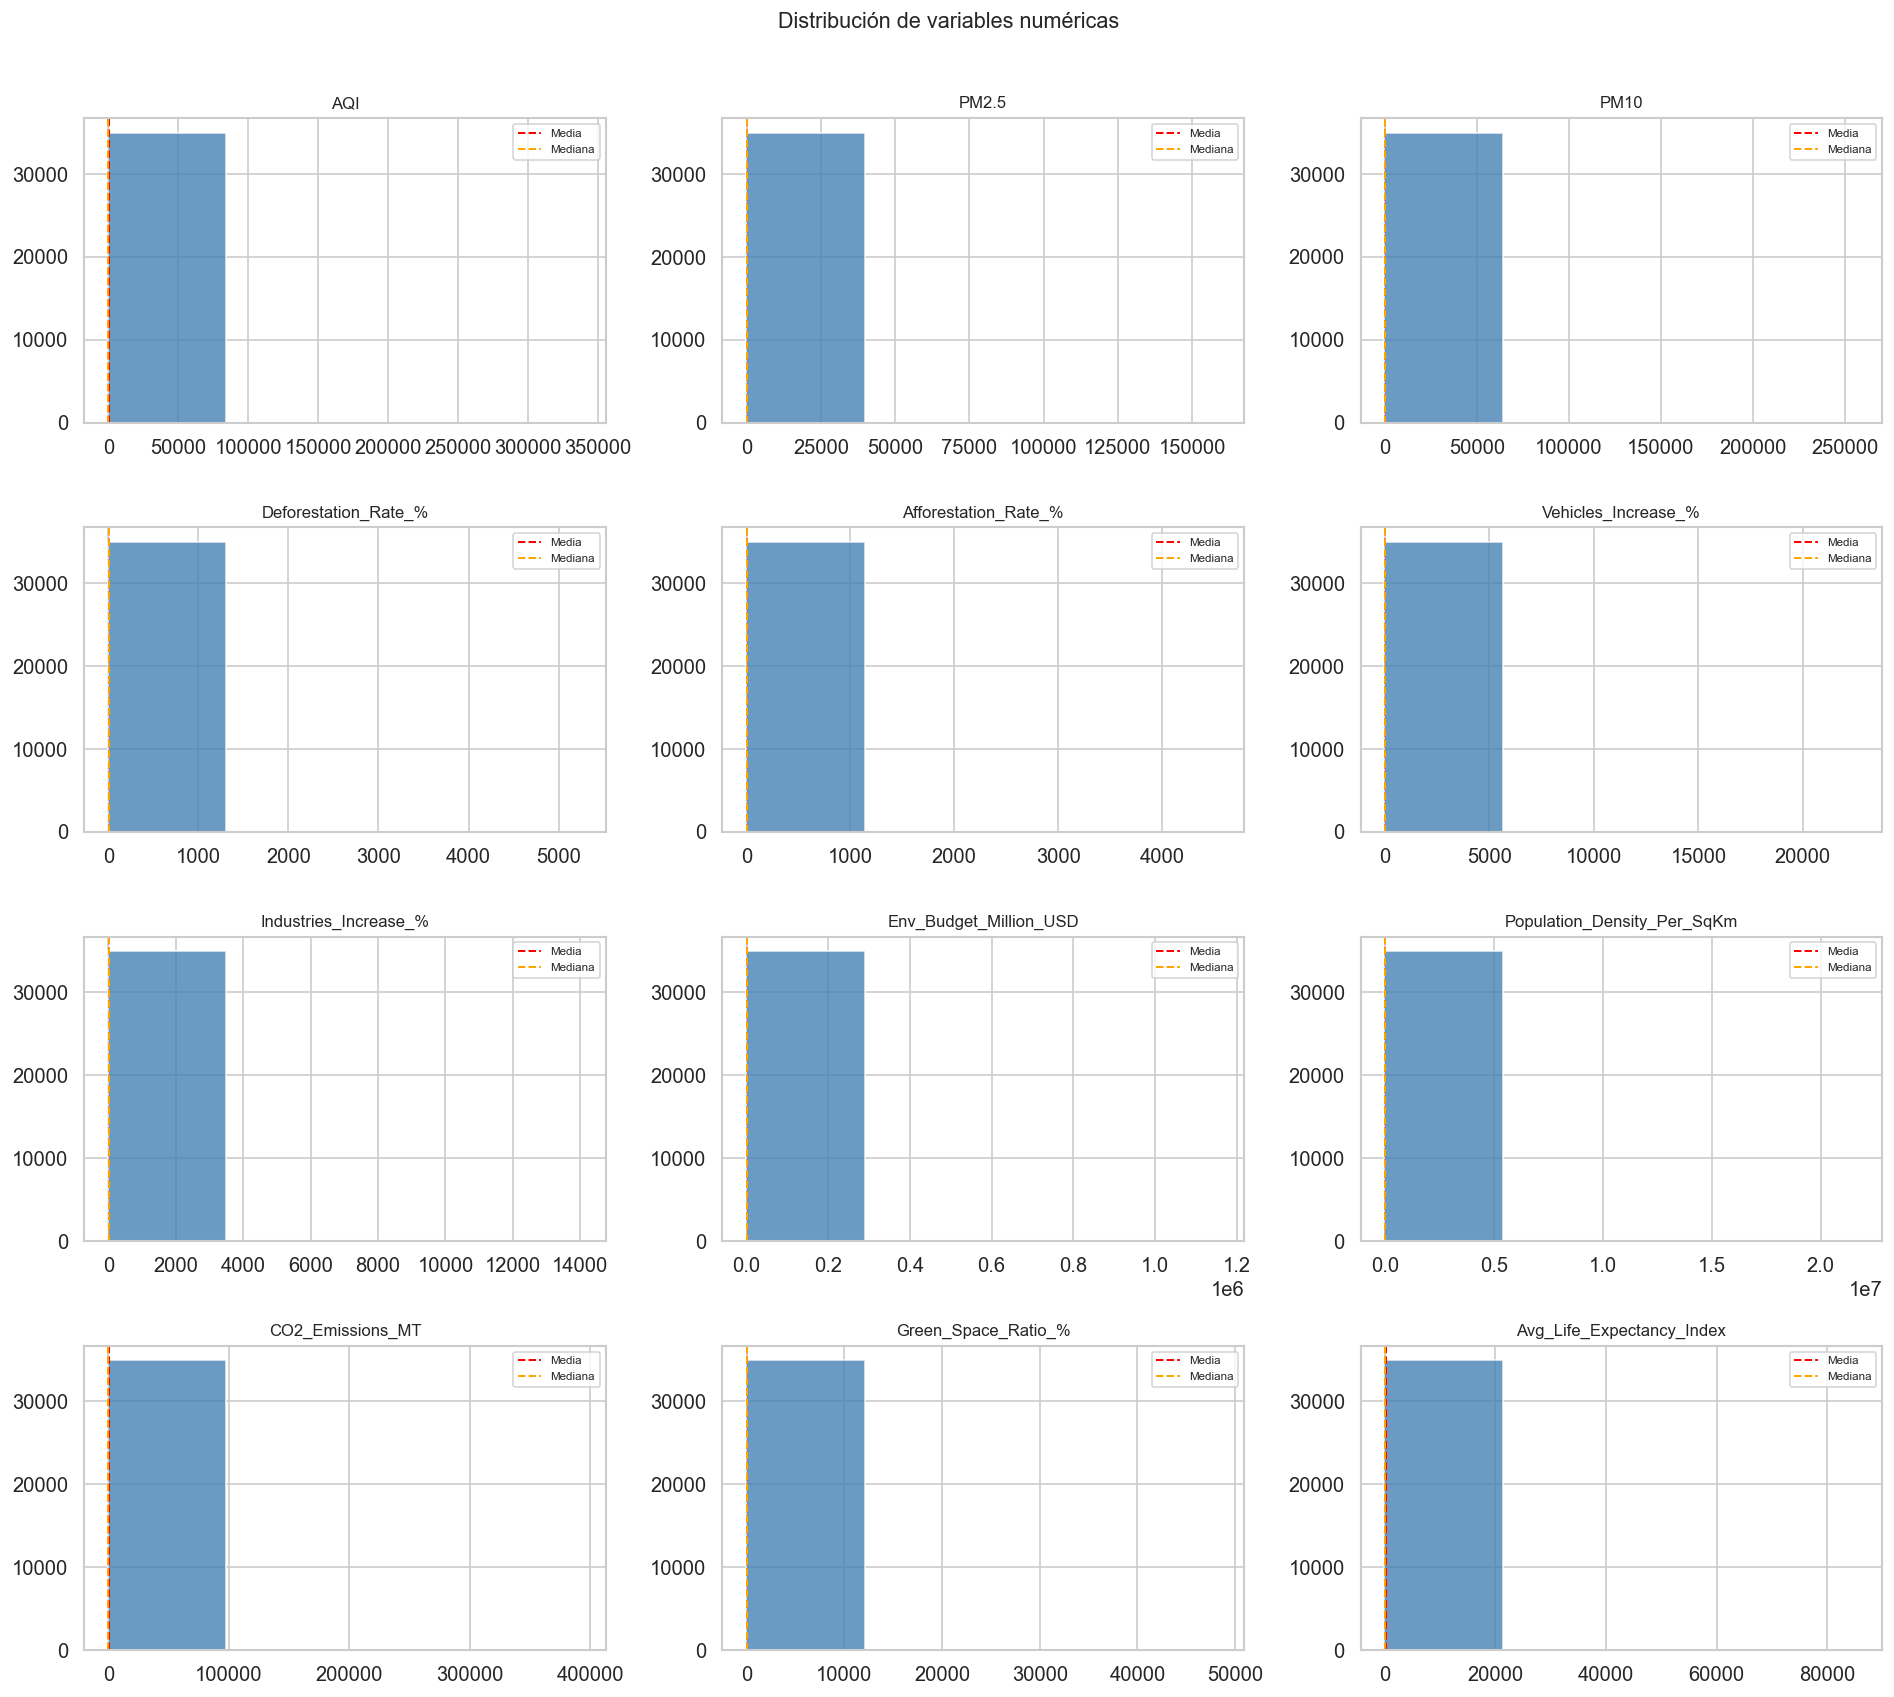

In [32]:
# Redefinir localmente por si la celda se ejecuta fuera de orden
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Excluir 'Year' de los histogramas (variable temporal, no continua)
hist_cols = [c for c in num_cols if c != 'Year']

n = len(hist_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(hist_cols):
    axes[i].hist(df[col], bins=4, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label='Media')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.2, label='Mediana')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

# Apagar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'eda_histogramas.png'), bbox_inches='tight')
plt.show()

### 2b.5 Detección y tratamiento de outliers (IQR)

Usamos el método IQR (rango intercuartílico) para identificar y eliminar outliers extremos. Se considera outlier un valor fuera del rango `[Q1 - 3×IQR, Q3 + 3×IQR]` (criterio conservador para no perder demasiados datos).

In [33]:
# Redefinir localmente por si la celda se ejecuta fuera de orden
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_cols = [c for c in num_cols if c != 'Year']

df_antes = len(df)
outlier_resumen = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_resumen.append({'Variable': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                            'IQR': round(IQR,2), 'Lower': round(lower,2),
                            'Upper': round(upper,2), 'Outliers': n_out})

resumen_out = pd.DataFrame(outlier_resumen)
print('=== OUTLIERS DETECTADOS (criterio 3×IQR) ===')
print(resumen_out[['Variable', 'Lower', 'Upper', 'Outliers']].to_string(index=False))

# Eliminar filas con outliers en cualquier variable
mask_clean = pd.Series([True] * len(df), index=df.index)
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    mask_clean &= (df[col] >= lower) & (df[col] <= upper)

df = df[mask_clean].reset_index(drop=True)
df_despues = len(df)

print()
print(f'Filas antes:   {df_antes:,}')
print(f'Filas después: {df_despues:,}')
print(f'Eliminadas:    {df_antes - df_despues:,} ({(df_antes - df_despues)/df_antes*100:.2f}%)')

=== OUTLIERS DETECTADOS (criterio 3×IQR) ===
                   Variable     Lower    Upper  Outliers
                        AQI   -274.24   519.95        93
                      PM2.5   -159.33   294.81        97
                       PM10   -257.49   479.65       100
       Deforestation_Rate_%     -7.37    11.95        77
       Afforestation_Rate_%     -4.38     7.73        95
        Vehicles_Increase_%    -17.86    35.27        86
      Industries_Increase_%    -12.29    24.53        94
     Env_Budget_Million_USD   -737.50  1236.44        86
Population_Density_Per_SqKm -20133.56 36248.52        76
           CO2_Emissions_MT   -226.33   573.60        97
        Green_Space_Ratio_%     -3.40    72.48       181
  Avg_Life_Expectancy_Index     49.25   105.53       261

Filas antes:   35,000
Filas después: 33,657
Eliminadas:    1,343 (3.84%)


### 2b.6 Boxplots post-limpieza

Verificamos visualmente que los outliers extremos fueron removidos.

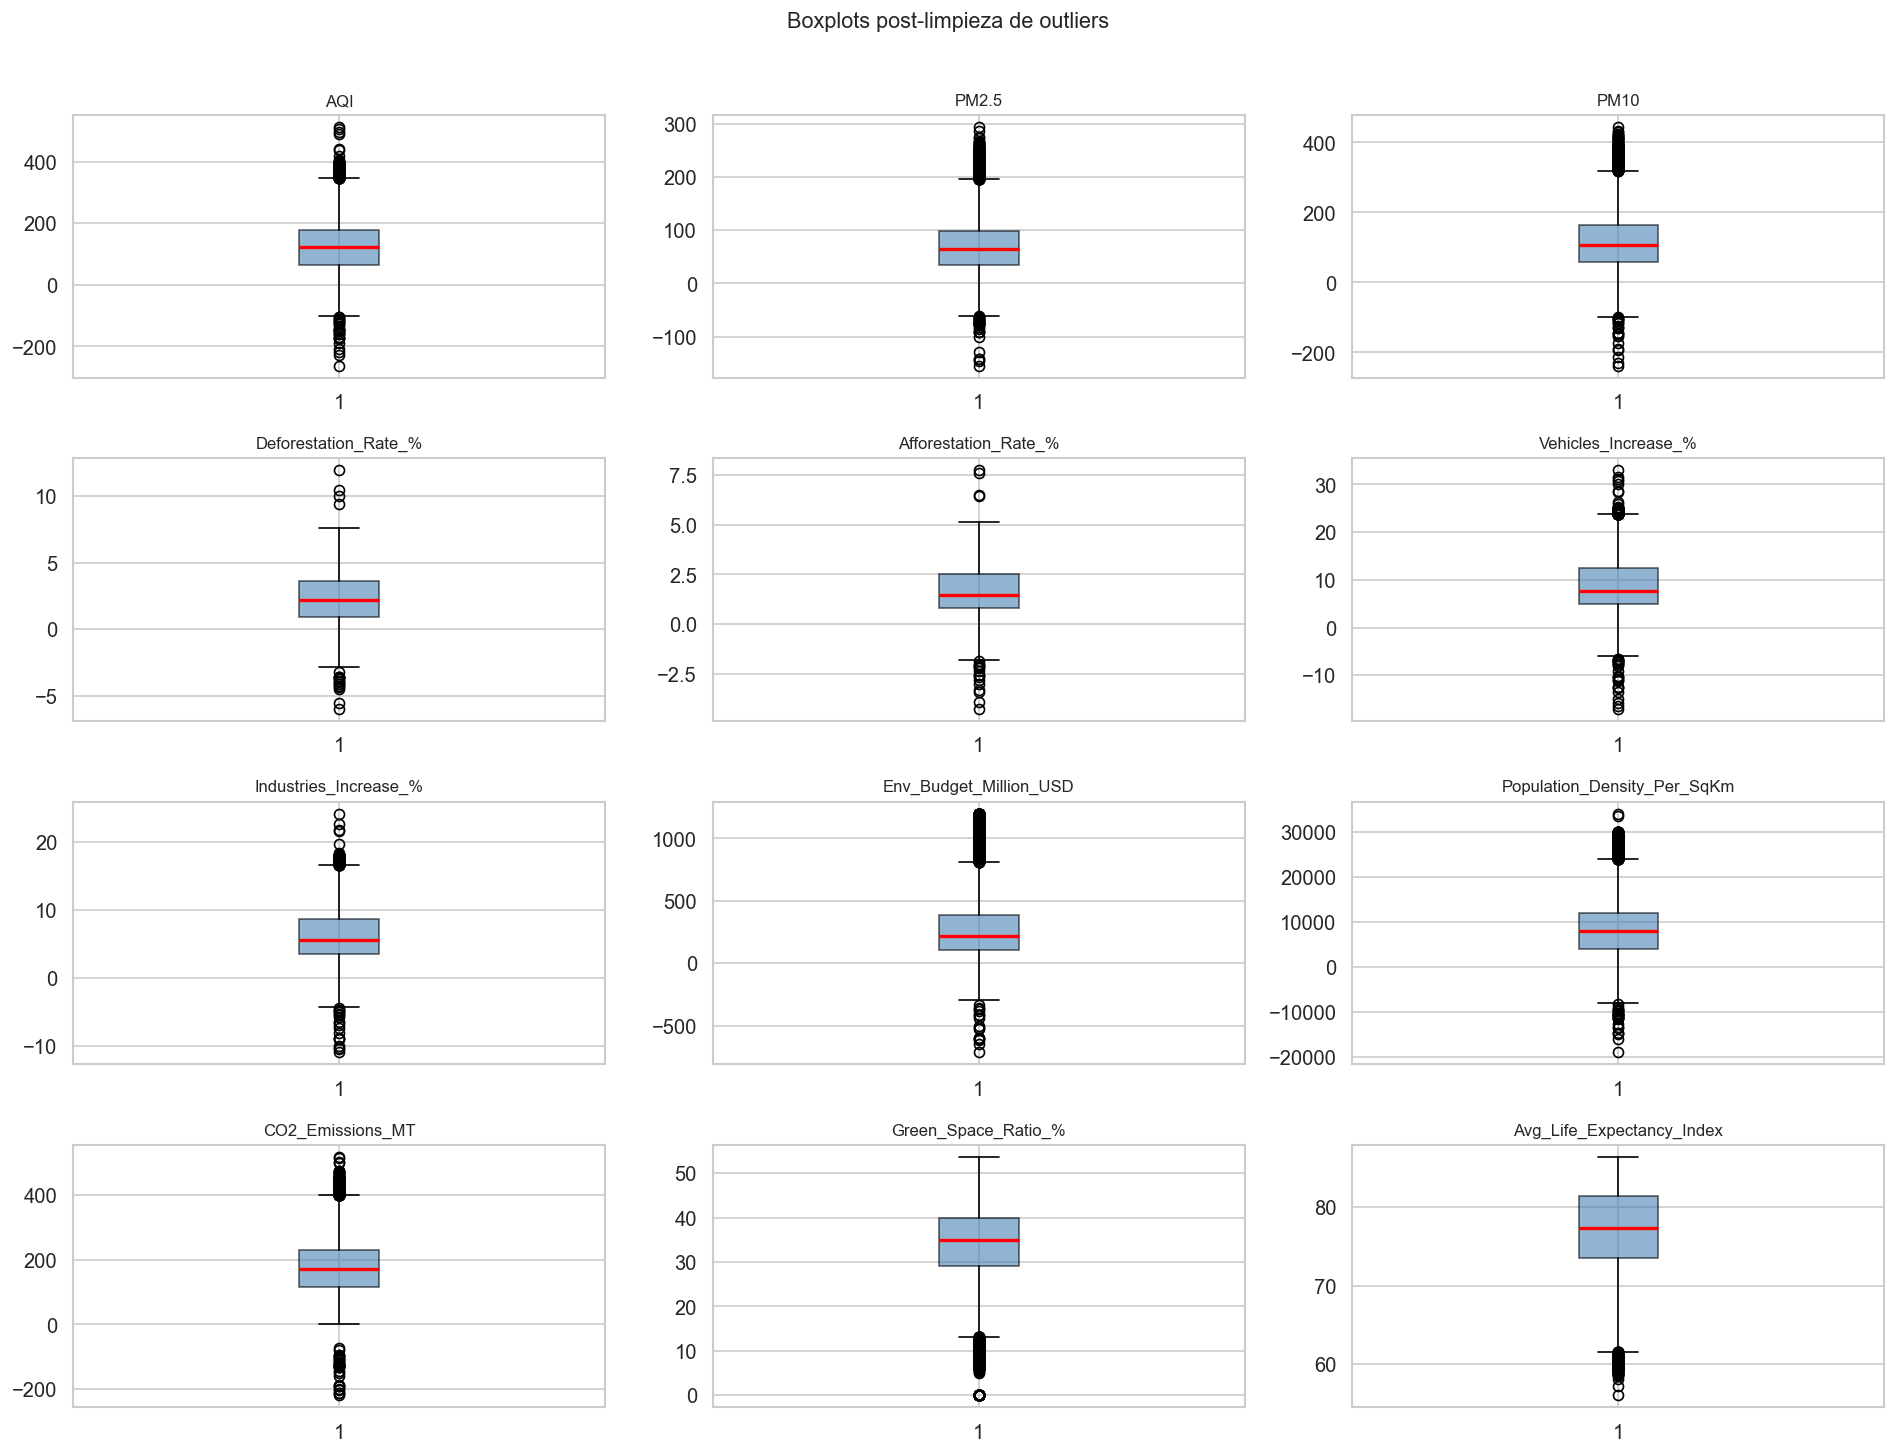

In [34]:
# Redefinir localmente por si la celda se ejecuta fuera de orden
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
hist_cols = [c for c in num_cols if c != 'Year']
n = len(hist_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(hist_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots post-limpieza de outliers', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'eda_boxplots_postlimpieza.png'), bbox_inches='tight')
plt.show()

### 2b.9 Conversión y validación final del dataset limpio

Confirmamos que todas las columnas que entrarán a PCA son numéricas y no tienen valores nulos.

In [35]:
# Variables que entrarán a PCA (definidas aquí para referencia)
FEATURES_CHECK = [
    'AQI', 'PM2.5', 'PM10',
    'Deforestation_Rate_%', 'Afforestation_Rate_%',
    'Vehicles_Increase_%', 'Industries_Increase_%',
    'Env_Budget_Million_USD', 'Population_Density_Per_SqKm',
    'CO2_Emissions_MT', 'Green_Space_Ratio_%', 'Avg_Life_Expectancy_Index'
]

# Verificar que todas existen y son numéricas
print('=== VALIDACIÓN PRE-PCA ===')
for col in FEATURES_CHECK:
    dtype = df[col].dtype
    nulls = df[col].isnull().sum()
    status = '✔' if (np.issubdtype(dtype, np.number) and nulls == 0) else '❌'
    print(f'{status} {col:35s} | dtype: {str(dtype):10s} | nulos: {nulls}')

print()
print(f'Dataset final listo para PCA:')
print(f'  Filas:    {len(df):,}')
print(f'  Features: {len(FEATURES_CHECK)}')
print(f'  Nulos:    {df[FEATURES_CHECK].isnull().sum().sum()}')

=== VALIDACIÓN PRE-PCA ===
✔ AQI                                 | dtype: float64    | nulos: 0
✔ PM2.5                               | dtype: float64    | nulos: 0
✔ PM10                                | dtype: float64    | nulos: 0
✔ Deforestation_Rate_%                | dtype: float64    | nulos: 0
✔ Afforestation_Rate_%                | dtype: float64    | nulos: 0
✔ Vehicles_Increase_%                 | dtype: float64    | nulos: 0
✔ Industries_Increase_%               | dtype: float64    | nulos: 0
✔ Env_Budget_Million_USD              | dtype: float64    | nulos: 0
✔ Population_Density_Per_SqKm         | dtype: float64    | nulos: 0
✔ CO2_Emissions_MT                    | dtype: float64    | nulos: 0
✔ Green_Space_Ratio_%                 | dtype: float64    | nulos: 0
✔ Avg_Life_Expectancy_Index           | dtype: float64    | nulos: 0

Dataset final listo para PCA:
  Filas:    33,657
  Features: 12
  Nulos:    0


## 3. Selección de variables para PCA

Se excluyen las variables categóricas (`Country`, `City`) y la variable temporal (`Year`), que no aportan información continua para la reducción de dimensionalidad.

In [36]:
# Variables numéricas continuas para PCA
FEATURES = [
    'AQI',
    'PM2.5',
    'PM10',
    'Deforestation_Rate_%',
    'Afforestation_Rate_%',
    'Vehicles_Increase_%',
    'Industries_Increase_%',
    'Env_Budget_Million_USD',
    'Population_Density_Per_SqKm',
    'CO2_Emissions_MT',
    'Green_Space_Ratio_%',
    'Avg_Life_Expectancy_Index'
]

X = df[FEATURES].copy()
print(f'Variables seleccionadas: {len(FEATURES)}')
print(FEATURES)

Variables seleccionadas: 12
['AQI', 'PM2.5', 'PM10', 'Deforestation_Rate_%', 'Afforestation_Rate_%', 'Vehicles_Increase_%', 'Industries_Increase_%', 'Env_Budget_Million_USD', 'Population_Density_Per_SqKm', 'CO2_Emissions_MT', 'Green_Space_Ratio_%', 'Avg_Life_Expectancy_Index']


## 4. Análisis de correlación

Antes de PCA, inspeccionamos la matriz de correlación para verificar que existen correlaciones entre variables (condición necesaria para que PCA sea útil).

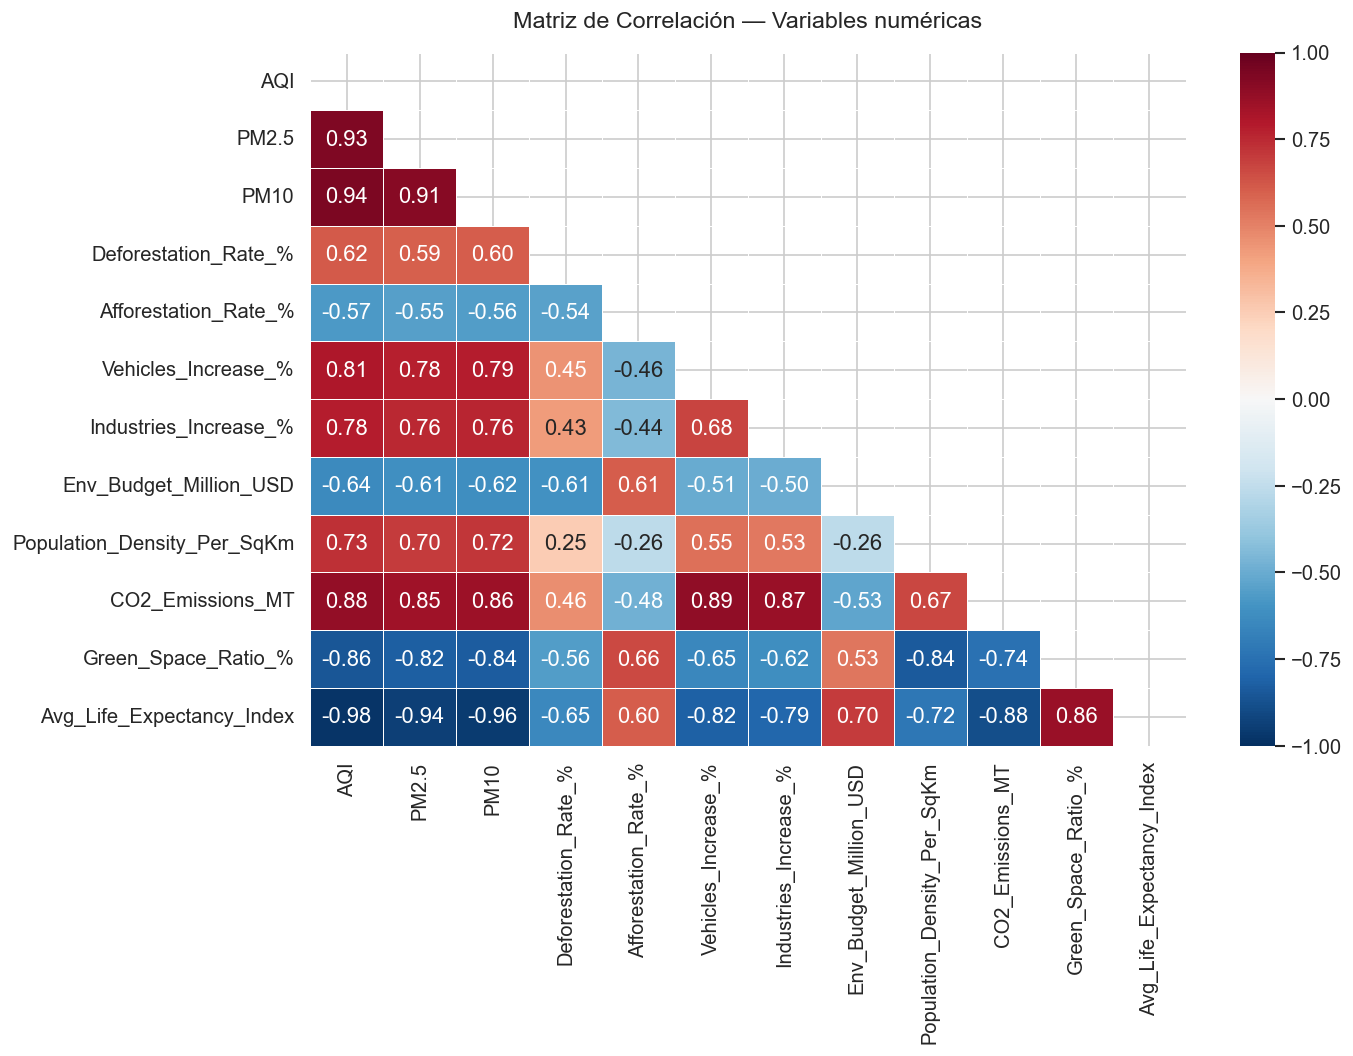

In [37]:
fig, ax = plt.subplots(figsize=(12, 9))

corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triángulo inferior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Matriz de Correlación — Variables numéricas', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'correlacion_heatmap.png'), bbox_inches='tight')
plt.show()

## 5. Estandarización

PCA es sensible a la escala. Se aplica `StandardScaler` (media=0, desviación estándar=1) para que ninguna variable domine por unidad de medida.

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificar estandarización
print('Media por variable (≈ 0):')
print(np.round(X_scaled.mean(axis=0), 4))
print()
print('Desviación estándar por variable (≈ 1):')
print(np.round(X_scaled.std(axis=0), 4))

Media por variable (≈ 0):
[-0. -0.  0.  0.  0.  0. -0.  0.  0. -0. -0. -0.]

Desviación estándar por variable (≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 6. PCA — Análisis de varianza explicada

Primero ajustamos PCA con todos los componentes para evaluar cuántos retener.

In [39]:
# PCA completo para evaluar varianza
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

# Varianza explicada individual y acumulada
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

# Tabla resumen
resumen_pca = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(var_exp))],
    'Eigenvalue': pca_full.explained_variance_,
    'Var. Explicada (%)': var_exp * 100,
    'Var. Acumulada (%)': var_cum * 100
})
print(resumen_pca.to_string(index=False))

Componente  Eigenvalue  Var. Explicada (%)  Var. Acumulada (%)
       PC1    8.588282           71.566890           71.566890
       PC2    1.173025            9.774922           81.341812
       PC3    0.668157            5.567808           86.909620
       PC4    0.480401            4.003221           90.912841
       PC5    0.366685            3.055622           93.968463
       PC6    0.321073            2.675525           96.643988
       PC7    0.159562            1.329643           97.973632
       PC8    0.093734            0.781091           98.754723
       PC9    0.051320            0.427656           99.182379
      PC10    0.045817            0.381800           99.564179
      PC11    0.039677            0.330632           99.894811
      PC12    0.012623            0.105189          100.000000


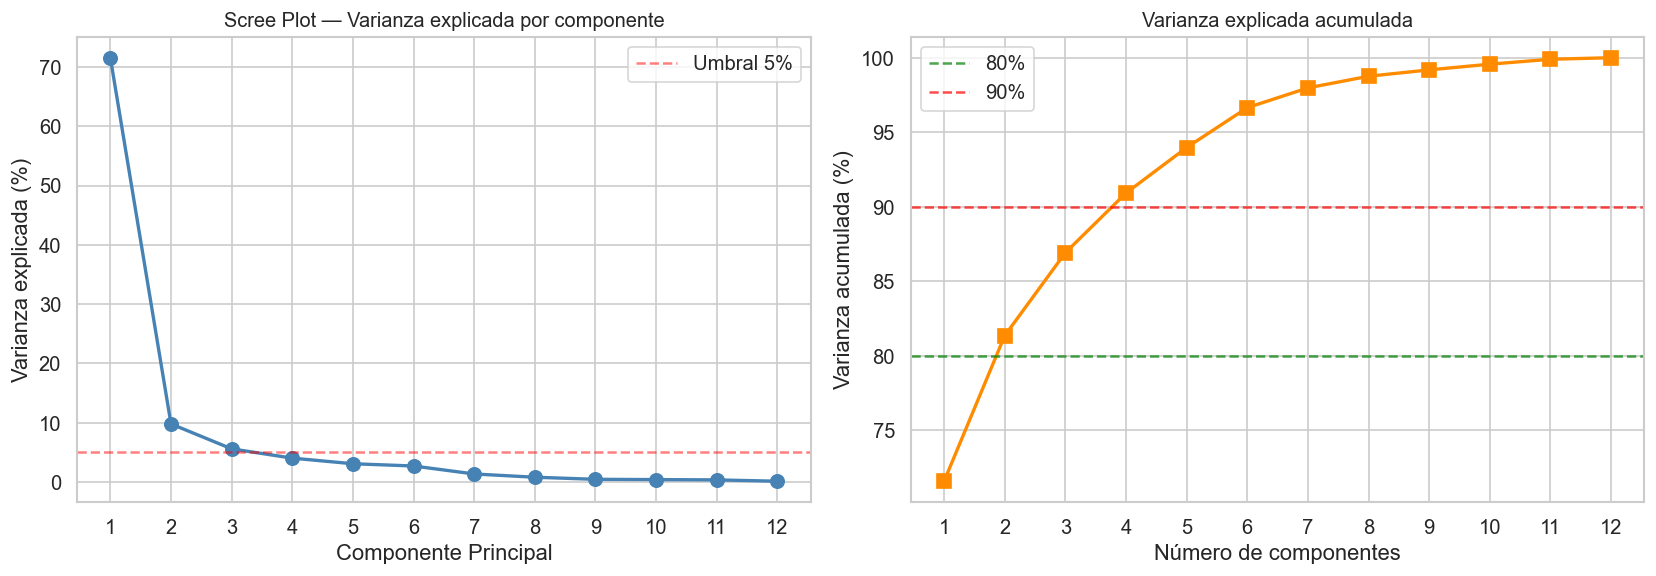

Componentes para explicar ≥80% de varianza: 2
Componentes para explicar ≥90% de varianza: 4


In [40]:
# Scree Plot + Varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_comp = len(var_exp)
x_ticks = range(1, n_comp + 1)

# --- Scree Plot ---
axes[0].plot(x_ticks, var_exp * 100, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Scree Plot — Varianza explicada por componente', fontsize=12)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_xticks(x_ticks)
axes[0].axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Umbral 5%')
axes[0].legend()

# --- Varianza acumulada ---
axes[1].plot(x_ticks, var_cum * 100, 's-', color='darkorange', linewidth=2, markersize=8)
axes[1].axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80%')
axes[1].axhline(y=90, color='red', linestyle='--', alpha=0.7, label='90%')
axes[1].set_title('Varianza explicada acumulada', fontsize=12)
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_xticks(x_ticks)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'pca_varianza_explicada.png'), bbox_inches='tight')
plt.show()

# Cuántos componentes para 80% y 90%
n_80 = np.argmax(var_cum >= 0.80) + 1
n_90 = np.argmax(var_cum >= 0.90) + 1
print(f'Componentes para explicar ≥80% de varianza: {n_80}')
print(f'Componentes para explicar ≥90% de varianza: {n_90}')

## 7. PCA final — Aplicar con n componentes seleccionados

In [41]:
# Seleccionar número de componentes (ajustar según scree plot)
N_COMPONENTS = n_80  # Componentes que explican ≥80% varianza

pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA aplicado con {N_COMPONENTS} componentes')
print(f'Varianza explicada total: {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'Shape original: {X_scaled.shape} → Shape reducido: {X_pca.shape}')

PCA aplicado con 2 componentes
Varianza explicada total: 81.34%
Shape original: (33657, 12) → Shape reducido: (33657, 2)


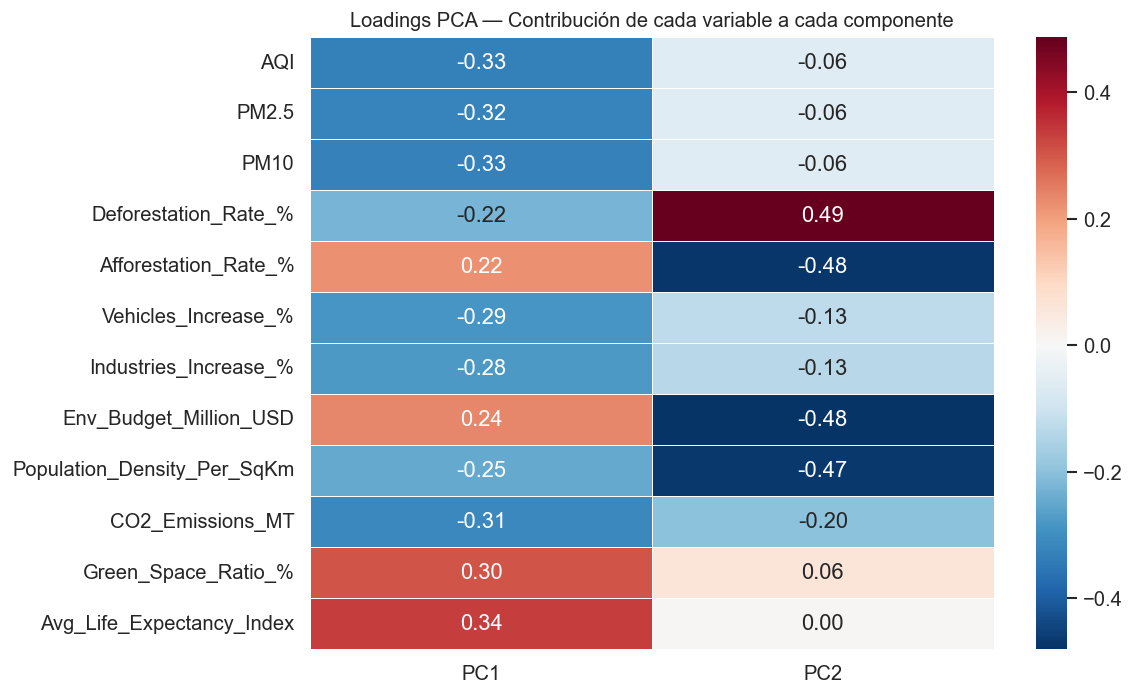


Loadings:
                               PC1    PC2
AQI                         -0.332 -0.057
PM2.5                       -0.322 -0.057
PM10                        -0.326 -0.058
Deforestation_Rate_%        -0.224  0.488
Afforestation_Rate_%         0.222 -0.476
Vehicles_Increase_%         -0.286 -0.128
Industries_Increase_%       -0.279 -0.134
Env_Budget_Million_USD       0.237 -0.481
Population_Density_Per_SqKm -0.249 -0.466
CO2_Emissions_MT            -0.311 -0.199
Green_Space_Ratio_%          0.304  0.062
Avg_Life_Expectancy_Index    0.337  0.005


In [42]:
# Loadings: contribución de cada variable a cada componente
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    loadings,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Loadings PCA — Contribución de cada variable a cada componente', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'pca_loadings.png'), bbox_inches='tight')
plt.show()

print('\nLoadings:')
print(loadings.round(3))

## 8. K-Means — Determinación del número óptimo de clusters

Se usan dos métodos complementarios:
- **Método del codo (Elbow):** busca el punto donde la inercia deja de disminuir significativamente
- **Silhouette Score:** mide qué tan bien separados están los clusters (más alto = mejor)

In [43]:
# Rango de k a evaluar
K_RANGE = range(2, 11)

inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    print(f'k={k} | Inercia: {km.inertia_:,.1f} | Silhouette: {silhouette_score(X_pca, labels):.4f}')

k=2 | Inercia: 136,961.0 | Silhouette: 0.5300
k=3 | Inercia: 59,675.9 | Silhouette: 0.5532
k=4 | Inercia: 43,483.7 | Silhouette: 0.4601
k=5 | Inercia: 34,605.9 | Silhouette: 0.4453
k=6 | Inercia: 27,678.3 | Silhouette: 0.4380
k=7 | Inercia: 23,994.4 | Silhouette: 0.3842
k=8 | Inercia: 21,255.5 | Silhouette: 0.3575
k=9 | Inercia: 19,145.8 | Silhouette: 0.3591
k=10 | Inercia: 17,169.9 | Silhouette: 0.3523


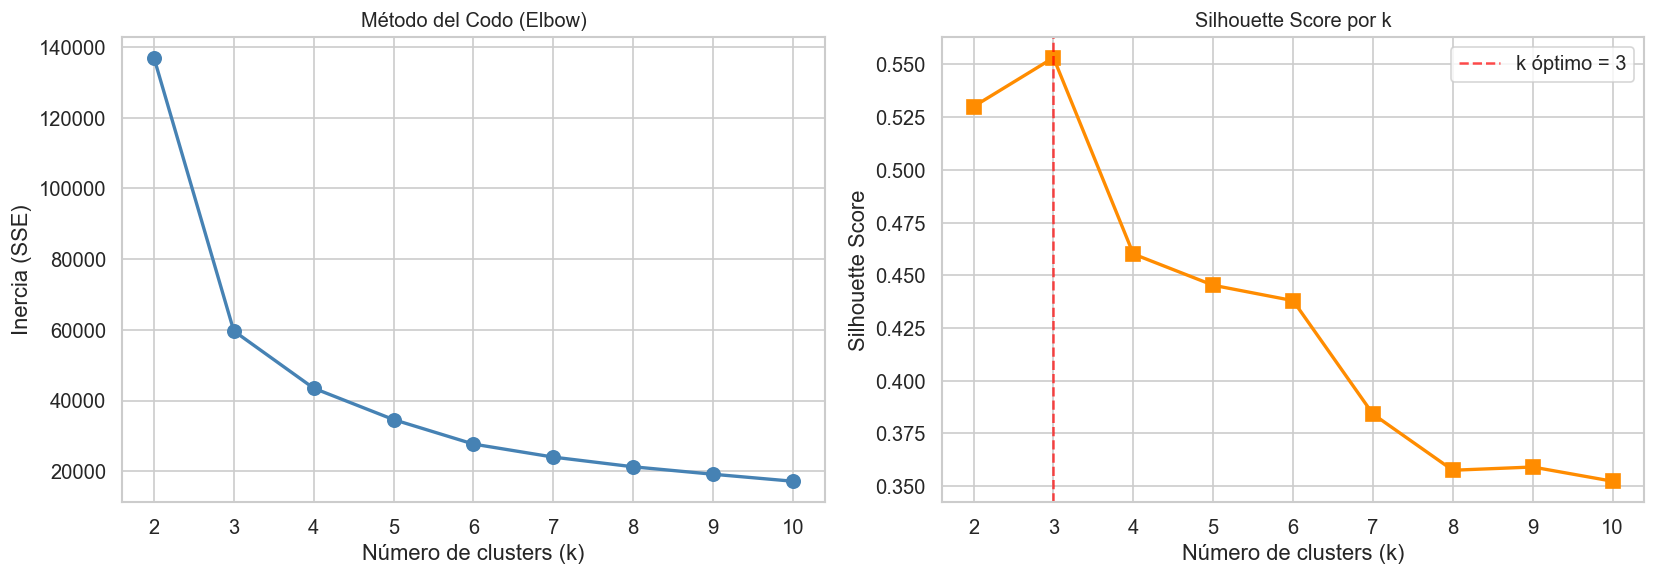

k sugerido por Silhouette Score: 3


In [44]:
# Visualización Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Método del Codo (Elbow)', fontsize=12)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia (SSE)')
axes[0].set_xticks(list(K_RANGE))

# Silhouette
axes[1].plot(list(K_RANGE), silhouettes, 's-', color='darkorange', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score por k', fontsize=12)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))

k_opt = list(K_RANGE)[np.argmax(silhouettes)]
axes[1].axvline(x=k_opt, color='red', linestyle='--', alpha=0.7, label=f'k óptimo = {k_opt}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'kmeans_elbow_silhouette.png'), bbox_inches='tight')
plt.show()

print(f'k sugerido por Silhouette Score: {k_opt}')

## 9. K-Means final

In [45]:
# Ajustar k según análisis previo (modificar si es necesario)
K_FINAL = k_opt

kmeans = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Agregar cluster al dataframe original
df['Cluster'] = clusters

print(f'K-Means ejecutado con k={K_FINAL}')
print(f'Silhouette Score final: {silhouette_score(X_pca, clusters):.4f}')
print()
print('Distribución de clusters:')
print(df['Cluster'].value_counts().sort_index())

K-Means ejecutado con k=3
Silhouette Score final: 0.5532

Distribución de clusters:
Cluster
0     9293
1    17585
2     6779
Name: count, dtype: int64


## 10. Visualización de clusters en espacio PCA

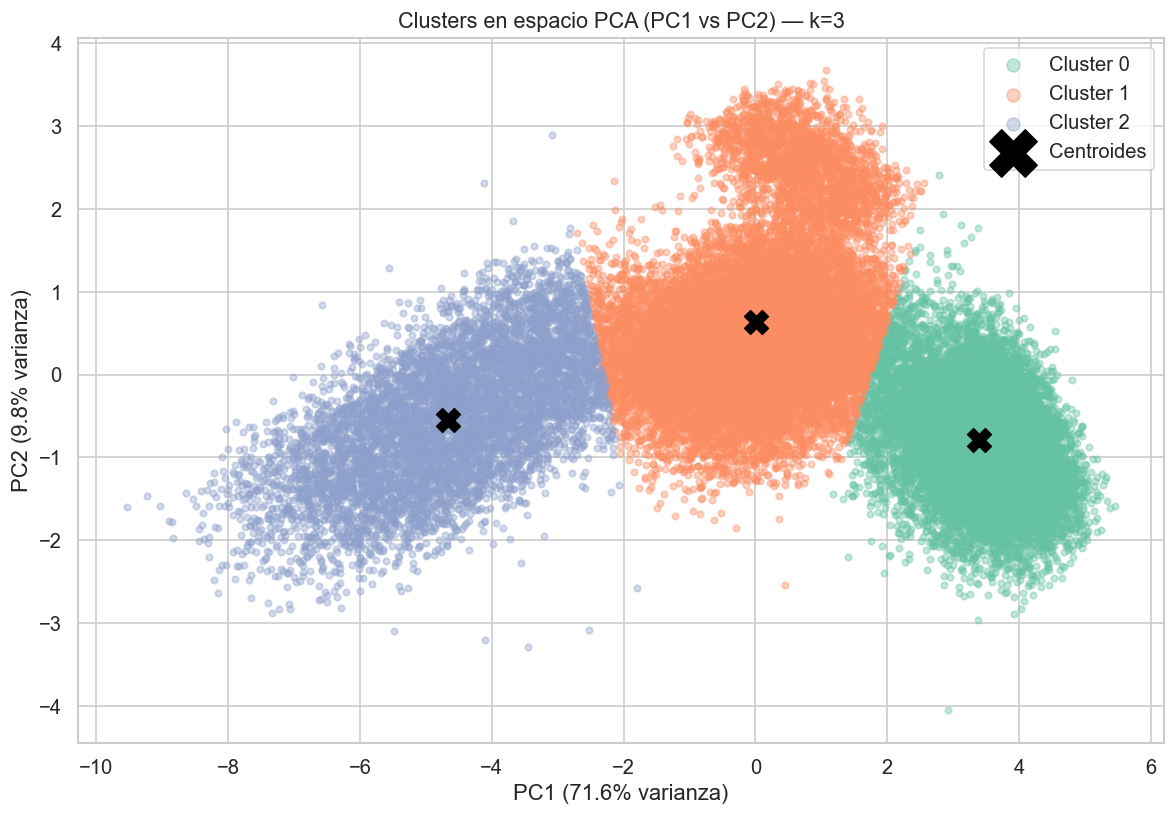

In [46]:
# Scatter plot PC1 vs PC2 coloreado por cluster
fig, ax = plt.subplots(figsize=(10, 7))

palette = sns.color_palette('Set2', K_FINAL)

for c in range(K_FINAL):
    mask = clusters == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f'Cluster {c}',
        alpha=0.4, s=15,
        color=palette[c]
    )

# Centroides
centroids_2d = kmeans.cluster_centers_[:, :2]
ax.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    c='black', marker='X', s=200, zorder=5, label='Centroides'
)

ax.set_title(f'Clusters en espacio PCA (PC1 vs PC2) — k={K_FINAL}', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'clusters_pca_scatter.png'), bbox_inches='tight')
plt.show()

## 11. Análisis Silhouette por muestra

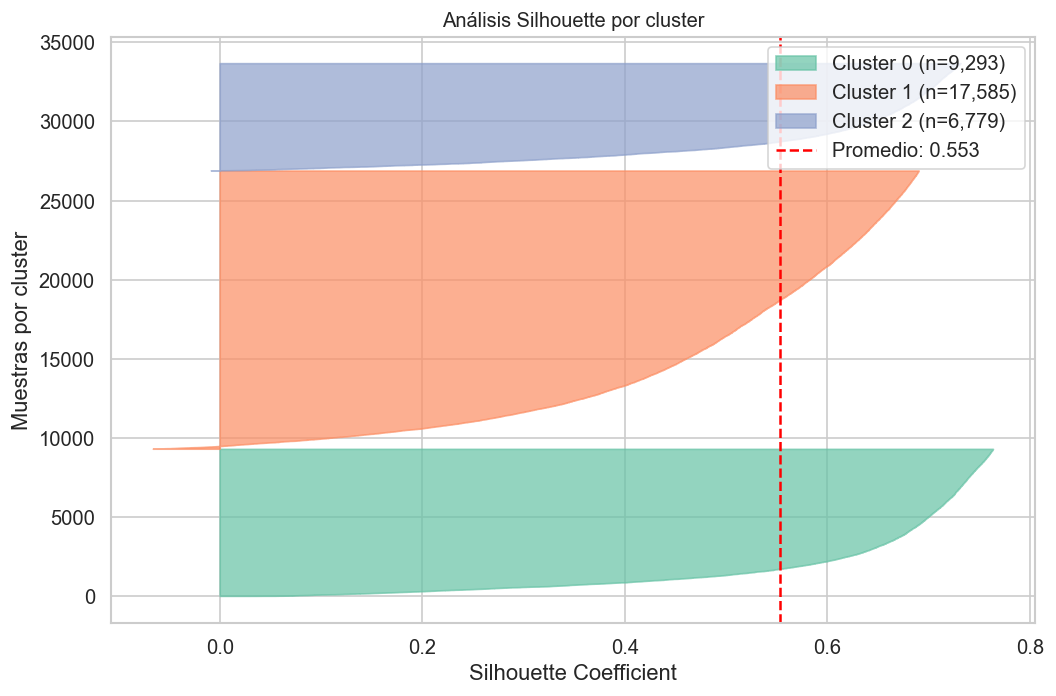

In [47]:
# Silhouette plot por cluster
silhouette_vals = silhouette_samples(X_pca, clusters)

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('Set2', K_FINAL)
y_lower = 10

for c in range(K_FINAL):
    c_silhouette = np.sort(silhouette_vals[clusters == c])
    size = len(c_silhouette)
    y_upper = y_lower + size
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, c_silhouette,
        alpha=0.7, color=palette[c], label=f'Cluster {c} (n={size:,})'
    )
    y_lower = y_upper + 10

avg_score = silhouette_score(X_pca, clusters)
ax.axvline(x=avg_score, color='red', linestyle='--', label=f'Promedio: {avg_score:.3f}')
ax.set_title('Análisis Silhouette por cluster', fontsize=12)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Muestras por cluster')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'clusters_silhouette.png'), bbox_inches='tight')
plt.show()

## 12. Perfilado estadístico de clusters

¿Qué caracteriza a cada cluster? Comparamos las medias de cada variable original por cluster.

In [48]:
# Medias por cluster
perfil = df.groupby('Cluster')[FEATURES].mean().round(2)
print('=== PERFIL ESTADÍSTICO POR CLUSTER ===')
print(perfil.T.to_string())

=== PERFIL ESTADÍSTICO POR CLUSTER ===
Cluster                            0        1         2
AQI                            38.73   128.73    268.79
PM2.5                          21.14    70.64    148.24
PM10                           34.75   115.71    242.34
Deforestation_Rate_%            0.65     2.77      3.77
Afforestation_Rate_%            3.07     1.46      0.81
Vehicles_Increase_%             4.10     8.62     17.59
Industries_Increase_%           2.84     6.12     12.08
Env_Budget_Million_USD        724.20   199.81    106.24
Population_Density_Per_SqKm  6142.00  7250.35  18166.45
CO2_Emissions_MT              103.36   174.57    328.71
Green_Space_Ratio_%            42.30    34.24     20.34
Avg_Life_Expectancy_Index      83.87    76.76     67.23


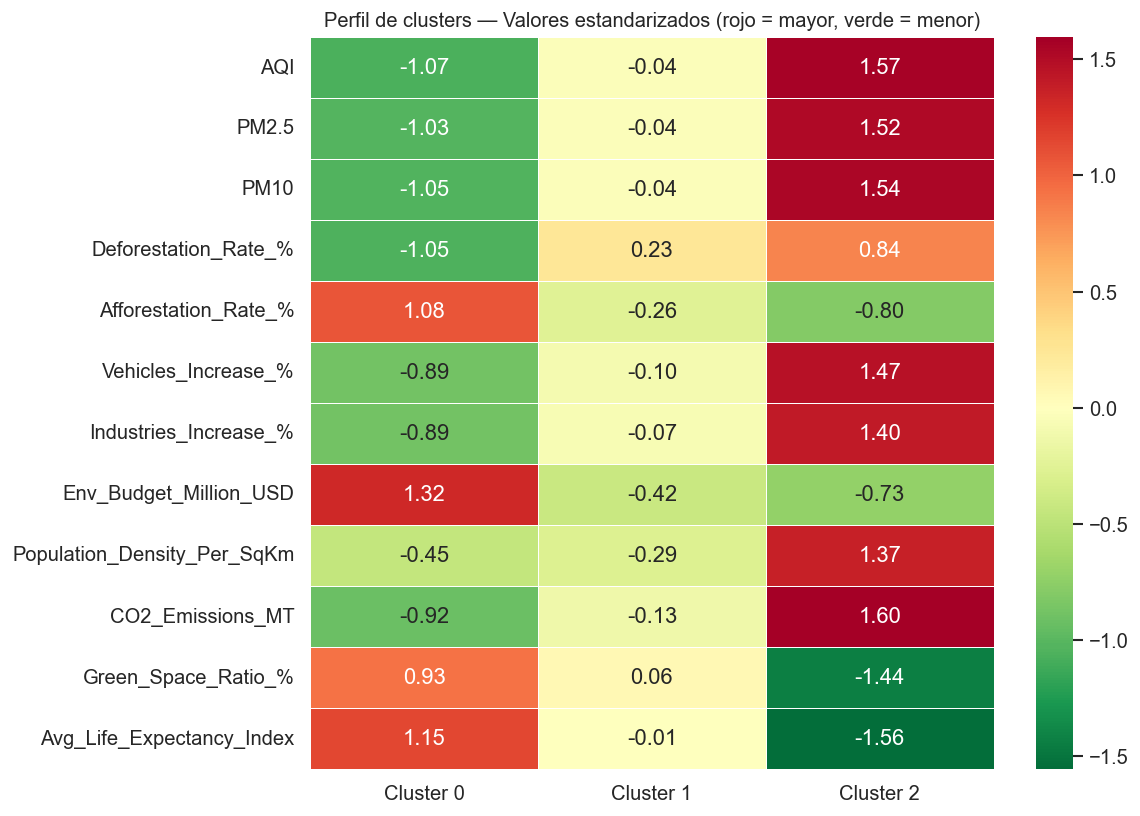

In [49]:
# Heatmap de perfiles — valores estandarizados para comparabilidad
perfil_scaled = pd.DataFrame(
    scaler.transform(perfil),
    index=perfil.index,
    columns=FEATURES
).T
perfil_scaled.columns = [f'Cluster {c}' for c in perfil_scaled.columns]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    perfil_scaled,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Perfil de clusters — Valores estandarizados (rojo = mayor, verde = menor)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'clusters_perfil_heatmap.png'), bbox_inches='tight')
plt.show()

In [50]:
# Distribución geográfica por cluster (Top países por cluster)
print('=== PAÍSES MÁS FRECUENTES POR CLUSTER ===')
for c in range(K_FINAL):
    top_paises = df[df['Cluster'] == c]['Country'].value_counts().head(5)
    print(f'\nCluster {c} (n={len(df[df["Cluster"]==c]):,}):')
    print(top_paises.to_string())

=== PAÍSES MÁS FRECUENTES POR CLUSTER ===

Cluster 0 (n=9,293):
Country
Australia    772
Spain        767
Sweden       765
Japan        745
France       744

Cluster 1 (n=17,585):
Country
Russia       818
Peru         769
Morocco      763
Indonesia    763
Ethiopia     761

Cluster 2 (n=6,779):
Country
Egypt         680
Bangladesh    679
Iran          677
Pakistan      677
Myanmar       673


C:\Users\Hin-j\AppData\Local\Temp\ipykernel_14024\1291223307.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Hin-j\AppData\Local\Temp\ipykernel_14024\1291223307.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Hin-j\AppData\Local\Temp\ipykernel_14024\1291223307.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Hin-j\AppData\Local\Temp\ipykernel_14024\1291223307.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

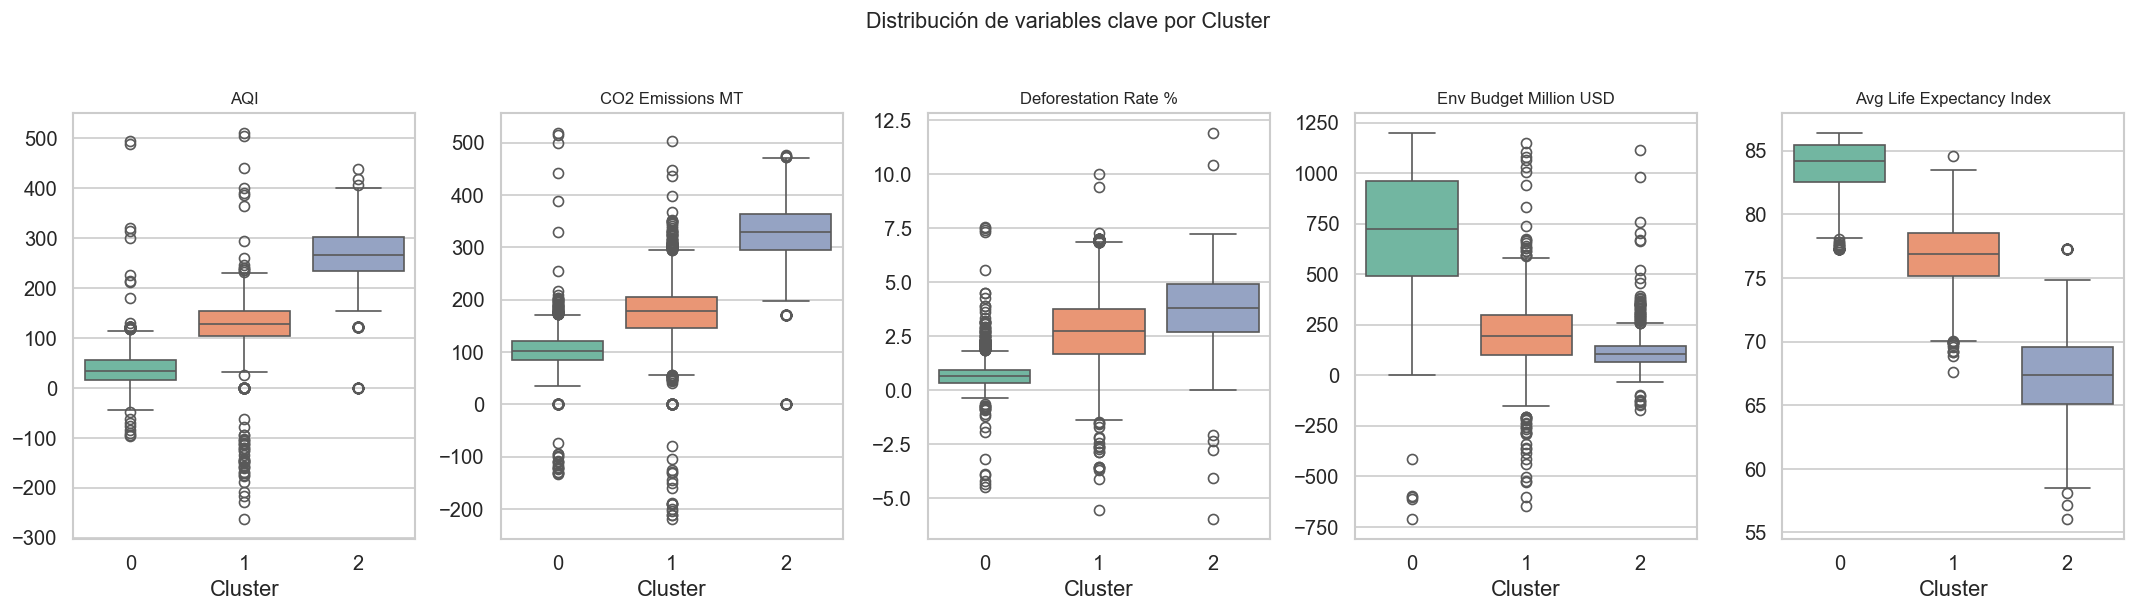

In [51]:
# Boxplots de variables clave por cluster
KEY_VARS = ['AQI', 'CO2_Emissions_MT', 'Deforestation_Rate_%', 
            'Env_Budget_Million_USD', 'Avg_Life_Expectancy_Index']

fig, axes = plt.subplots(1, len(KEY_VARS), figsize=(18, 5))

for i, var in enumerate(KEY_VARS):
    sns.boxplot(
        data=df, x='Cluster', y=var,
        palette='Set2', ax=axes[i]
    )
    axes[i].set_title(var.replace('_', ' '), fontsize=10)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('')

plt.suptitle('Distribución de variables clave por Cluster', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'clusters_boxplots_variables_clave.png'), bbox_inches='tight')
plt.show()

## 14. Resumen 

Cluster 0 — "Gestión Ambiental Avanzada" (n=9,598)
España · Suecia · Australia · Canadá · Japón

AQI, PM2.5, PM10 y CO₂ muy por debajo del promedio (−1.0 a −1.1)
Mayor presupuesto ambiental del grupo (+1.34)
Alta reforestación (+1.10) y áreas verdes (+0.96)
Esperanza de vida más alta (+1.15)


Cluster 1 — "Economías en Transición" (n=18,276)
Rusia · Etiopía · Indonesia · Perú · Sudáfrica

Todos los indicadores cercanos a 0 — perfil neutro/promedio
Ligera deforestación por encima del promedio (+0.24)
Menor inversión ambiental que Cluster 0
Grupo más heterogéneo y numeroso


Cluster 2 — "Crisis Ambiental y Presión Demográfica" (n=7,126)
Egipto · Irán · Pakistán · Bangladesh · Myanmar

AQI (+1.58), CO₂ (+1.62) y partículas (+1.53/+1.55) — los más altos
Vehículos (+1.49) e industrias (+1.42) creciendo sin regulación
Menor esperanza de vida (−1.55) y casi sin áreas verdes (−1.46)
Alta densidad poblacional agrava el impacto (+1.37)